### When to use Unsupervised ML?
#### Labeling is expensive and time consuming
#### Dimensionality reduction
#### Association Rule Mining - what products are often bought together

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns


In [ ]:
!pip install tensorflow

  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached charset_normalizer-3.4.3-cp311-cp311-win_amd64.whl.metadata (37 kB)
  Using cached idna-3.10-py3-none-any.whl.metadata (10 kB)
  Using cached urllib3-2.5.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached certifi-2025.8.3-py3-none-any.whl.metadata (2.4 kB)
   ---------------------------------------- 0.0/331.8 MB ? eta -:--:--
   ---------------------------------------- 1.0/331.8 MB 8.4 MB/s eta 0:00:40
   ---------------------------------------- 2.1/331.8 MB 6.9 MB/s eta 0:00:48
    --------------------------------------- 4.2/331.8 MB 7.6 MB/s eta 0:00:43
    --------------------------------------- 6.0/331.8 MB 8.4 MB/s eta 0:00:39
    --------------------------------------- 7.3/331.8 MB 7.8 MB/s eta 0:00:42
   - -------------------------------------- 8.7/331.8 MB 7.8 MB/s eta 0:00:42
   - -------------------------------------- 9.4/331.8 MB 7.1 MB/s eta 0:00:46
   - -------------------------------------- 

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\user\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\absl\\testing\\flagsaver.py'
Check the permissions.



In [2]:
%pip install keras

  Using cached keras-3.11.3-py3-none-any.whl.metadata (5.9 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached rich-14.1.0-py3-none-any.whl.metadata (18 kB)
  Using cached h5py-3.14.0-cp311-cp311-win_amd64.whl.metadata (2.7 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
Using cached keras-3.11.3-py3-none-any.whl (1.4 MB)
Using cached absl_py-2.3.1-py3-none-any.whl (135 kB)
Using cached h5py-3.14.0-cp311-cp311-win_amd64.whl (2.9 MB)
Using cached rich-14.1.0-py3-none-any.whl (243 kB)
Using cached markdown_it_py-4.0.0-py3-none-any.whl (87 kB)

   ---------------------------------------- 0/5 [markdown-it-py]
   ---------------------------------------- 0/5 [markdown-it-py]
   ---------------------------------------- 0/5 [markdown-it-py]
   ---------------------------------------- 0/5 [markdown-it-py]
   ---------------------------------------- 0/5 [markdown-it-py]
   ---------------------------------------- 0/5 [markdown-it-py]
   -

In [2]:
df = pd.read_csv("Live.csv")

In [3]:
df.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


In [4]:
df.dtypes

status_id            object
status_type          object
status_published     object
num_reactions         int64
num_comments          int64
num_shares            int64
num_likes             int64
num_loves             int64
num_wows              int64
num_hahas             int64
num_sads              int64
num_angrys            int64
Column1             float64
Column2             float64
Column3             float64
Column4             float64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   object 
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(9), object(3)
memory 

In [6]:
duplicate_rows_df = df[df.duplicated()]
duplicate_rows_df.shape

(51, 16)

In [7]:
df.count()

status_id           7050
status_type         7050
status_published    7050
num_reactions       7050
num_comments        7050
num_shares          7050
num_likes           7050
num_loves           7050
num_wows            7050
num_hahas           7050
num_sads            7050
num_angrys          7050
Column1                0
Column2                0
Column3                0
Column4                0
dtype: int64

In [8]:
df.drop(['Column1', 'Column2', 'Column3', 'Column4'], inplace=True, axis =1)

In [9]:
df.shape

(7050, 12)

In [10]:
len(df['status_id'].unique())

6997

In [11]:
len(df['status_published'].unique())

6913

In [12]:
len(df['status_type'].unique())

4

### Only this object column has 4 (less) unique values

In [13]:
df.drop(['status_id', 'status_published'], inplace=True, axis =1)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   status_type    7050 non-null   object
 1   num_reactions  7050 non-null   int64 
 2   num_comments   7050 non-null   int64 
 3   num_shares     7050 non-null   int64 
 4   num_likes      7050 non-null   int64 
 5   num_loves      7050 non-null   int64 
 6   num_wows       7050 non-null   int64 
 7   num_hahas      7050 non-null   int64 
 8   num_sads       7050 non-null   int64 
 9   num_angrys     7050 non-null   int64 
dtypes: int64(9), object(1)
memory usage: 550.9+ KB


In [15]:
df.describe()

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000
mean,230.117163,224.356028,40.022553,215.043121,12.728652,1.289362,0.696454,0.243688,0.113191
std,462.625309,889.636820,131.599965,449.472357,39.972930,8.719650,3.957183,1.597156,0.726812
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,59.500000,4.000000,0.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,219.000000,23.000000,4.000000,184.750000,3.000000,0.000000,0.000000,0.000000,0.000000
max,4710.000000,20990.000000,3424.000000,4710.000000,657.000000,278.000000,157.000000,51.000000,31.000000


In [16]:
df.shape

(7050, 10)

### Take all data in training and put relavant column in y to label the groups

In [34]:
df['status_type'].unique()

array([3, 1, 0, 2])

In [35]:
X= df
y = df['status_type']

### Convert categorical data into integer type

In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X['status_type'] = le.fit_transform(X['status_type'])
y = le.transform(y)

In [37]:
X.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,3,529,512,262,432,92,3,1,1,0
1,1,150,0,0,150,0,0,0,0,0
2,3,227,236,57,204,21,1,1,0,0
3,1,111,0,0,111,0,0,0,0,0
4,1,213,0,0,204,9,0,0,0,0


In [38]:
y

array([3, 1, 3, ..., 1, 1, 1], shape=(7050,))

In [39]:
X['status_type'].unique()

array([3, 1, 0, 2])

In [40]:
cols = X.columns

In [41]:
from sklearn.preprocessing import MinMaxScaler

ms = MinMaxScaler()

X = ms.fit_transform(X)

In [ ]:
X

In [43]:
X= pd.DataFrame(X, columns=[cols])

In [47]:
X

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,1.000000,0.112314,0.024393,0.076519,0.091720,0.140030,0.010791,0.006369,0.019608,0.0
1,0.333333,0.031847,0.000000,0.000000,0.031847,0.000000,0.000000,0.000000,0.000000,0.0
2,1.000000,0.048195,0.011243,0.016647,0.043312,0.031963,0.003597,0.006369,0.000000,0.0
3,0.333333,0.023567,0.000000,0.000000,0.023567,0.000000,0.000000,0.000000,0.000000,0.0
4,0.333333,0.045223,0.000000,0.000000,0.043312,0.013699,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...
7045,0.333333,0.018896,0.000000,0.000000,0.018896,0.000000,0.000000,0.000000,0.000000,0.0
7046,0.333333,0.003397,0.000000,0.000000,0.002972,0.001522,0.000000,0.006369,0.000000,0.0
7047,0.333333,0.000425,0.000000,0.000000,0.000212,0.001522,0.000000,0.000000,0.000000,0.0
7048,0.333333,0.074522,0.000572,0.006425,0.074098,0.003044,0.000000,0.000000,0.000000,0.0


### K-means model with two clusters

In [48]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 2, random_state=0)

kmeans.fit(X)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [49]:
kmeans.cluster_centers_

array([[9.54921576e-01, 6.46330441e-02, 2.67028654e-02, 2.93171709e-02,
        5.71231462e-02, 4.71007076e-02, 8.18581889e-03, 9.65207685e-03,
        8.04219428e-03, 7.19501847e-03],
       [3.28506857e-01, 3.90710874e-02, 7.54854864e-04, 7.53667113e-04,
        3.85438884e-02, 2.17448568e-03, 2.43721364e-03, 1.20039760e-03,
        2.75348016e-03, 1.45313276e-03]])

In [50]:
kmeans.inertia_

237.75726404419547

In [52]:
labels = kmeans.labels_

correct_labels = sum (y == labels)

print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))

print('Accuracy score: {0:0.2f}'.format(correct_labels/float(y.size)))

Result: 4288 out of 7050 samples were correctly labeled.
Accuracy score: 0.61


In [63]:
## trying for 4 points
kmeans4 = KMeans(n_clusters = 4, random_state=0)

kmeans4.fit(X)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [64]:
labels = kmeans4.labels_

correct_labels = sum (y == labels)

print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))

print('Accuracy score: {0:0.2f}'.format(correct_labels/float(y.size)))

Result: 4112 out of 7050 samples were correctly labeled.
Accuracy score: 0.58


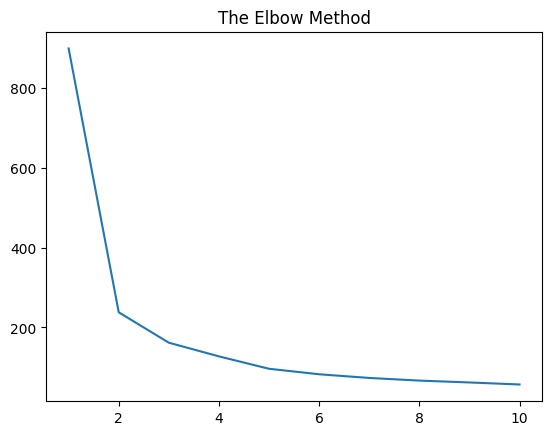

In [58]:
from scipy.stats import mode

cs =[]
accuracies = []

for i in range(1,11):
    kmeans3 = KMeans(n_clusters = i, init = 'k-means++', max_iter= 300, n_init= 10, random_state=0)
    kmeans3.fit(X)
    cs.append(kmeans3.inertia_)


plt.plot(range(1,11), cs)
plt.title('The Elbow Method')
plt.show()

For k = 1
Result: 4288 out of 7050 samples were correctly labeled.
Accuracy score: 0.61
For k = 2
Result: 6622 out of 7050 samples were correctly labeled.
Accuracy score: 0.94
For k = 3
Result: 6581 out of 7050 samples were correctly labeled.
Accuracy score: 0.93
For k = 4
Result: 6622 out of 7050 samples were correctly labeled.
Accuracy score: 0.94
For k = 5
Result: 6956 out of 7050 samples were correctly labeled.
Accuracy score: 0.99
For k = 6
Result: 6933 out of 7050 samples were correctly labeled.
Accuracy score: 0.98
For k = 7
Result: 6933 out of 7050 samples were correctly labeled.
Accuracy score: 0.98
For k = 8
Result: 6933 out of 7050 samples were correctly labeled.
Accuracy score: 0.98
For k = 9
Result: 6933 out of 7050 samples were correctly labeled.
Accuracy score: 0.98
For k = 10
Result: 7044 out of 7050 samples were correctly labeled.
Accuracy score: 1.00


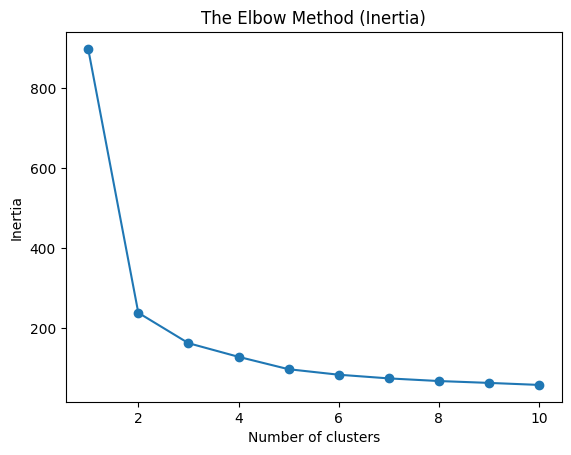

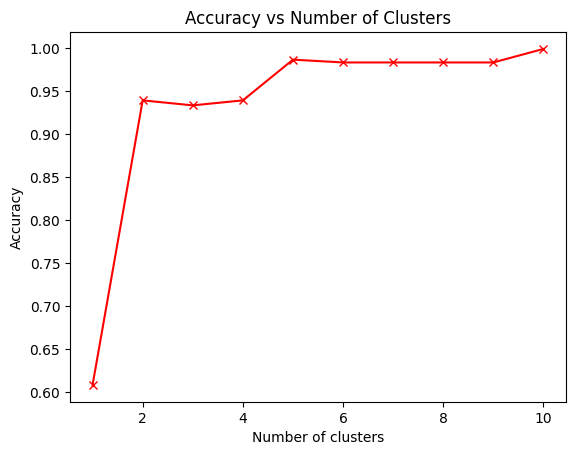

In [ ]:
from scipy.stats import mode
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

cs = []
accuracies = []

for i in range(1, 11):
    kmeans3 = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    labels = kmeans3.fit_predict(X)
    cs.append(kmeans3.inertia_)

    # Compute accuracy for every k (using best label matching)
    corrected_labels = np.zeros_like(labels)
    for j in range(i):
        mask = (labels == j)
        if np.any(mask):  # avoid empty cluster error
            corrected_labels[mask] = mode(y[mask], keepdims=True)[0]

    correct_labels = np.sum(corrected_labels == y)
    accuracy = correct_labels / float(y.size)
    accuracies.append(accuracy)

    print("For k =", i)
    print("Result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
    print('Accuracy score: {0:0.2f}'.format(accuracy))

# Plot inertia
plt.plot(range(1, 11), cs, marker='o')
plt.title('The Elbow Method (Inertia)')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

# Plot accuracy
plt.plot(range(1, 11), accuracies, marker='x', color='red')
plt.title('Accuracy vs Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Accuracy')
plt.show()


In [61]:
accuracies

[np.float64(0.9815602836879432)]

ValueError: x and y must have same first dimension, but have shapes (10,) and (1,)

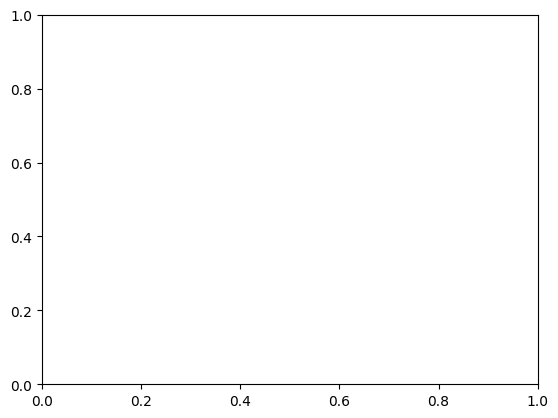

In [60]:
plt.plot(range(1, 11), accuracies, marker='x', color='red')
plt.title('Accuracy vs Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Accuracy')
plt.show()